## 2.1 Load & Inspect data

In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv(r"E:\Youssef\faculty of science\Ai Course\iti\Ai and machine learning foundation level 1\project\notebooks\house_prices.csv")

# Inspect the data
print("Shape of dataset:", df.shape)
print("\n--- Head ---")
display(df.head())

print("\n--- Info ---")
df.info()

print("\n--- Describe ---")
display(df.describe())

print("\n--- Missing Values % ---")
print(df.isna().mean().sort_values(ascending=False))

Shape of dataset: (187531, 21)

--- Head ---


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN



--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16 

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN



--- Missing Values % ---
Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Title                0.000000
location             0.000000
Amount(in rupees)    0.000000
Index                0.000000
dtype: float64


**Data Summary:**
* **How many rows?** The dataset contains approximately 187531 rows.
* **Which columns are numeric vs text?**
numerical =>
  Index              
  ,Price (in rupees)
  ,Dimensions
  ,Plot Area

text =>
  Title
  ,Description
  ,Amount(in rupees)
  ,location
  ,Carpet Area
  ,Status
  ,Floor
  ,Transaction
  ,Furnishing
  ,facing
  ,overlooking
  ,Society
  ,Bathroom
  ,Balcony
  ,Car Parking
  ,Ownership
  ,Super Area

* **Which columns have the most missing values?** Dimensions
  and Plot Area

## 2.2 Exploratory Data Analysis (EDA)

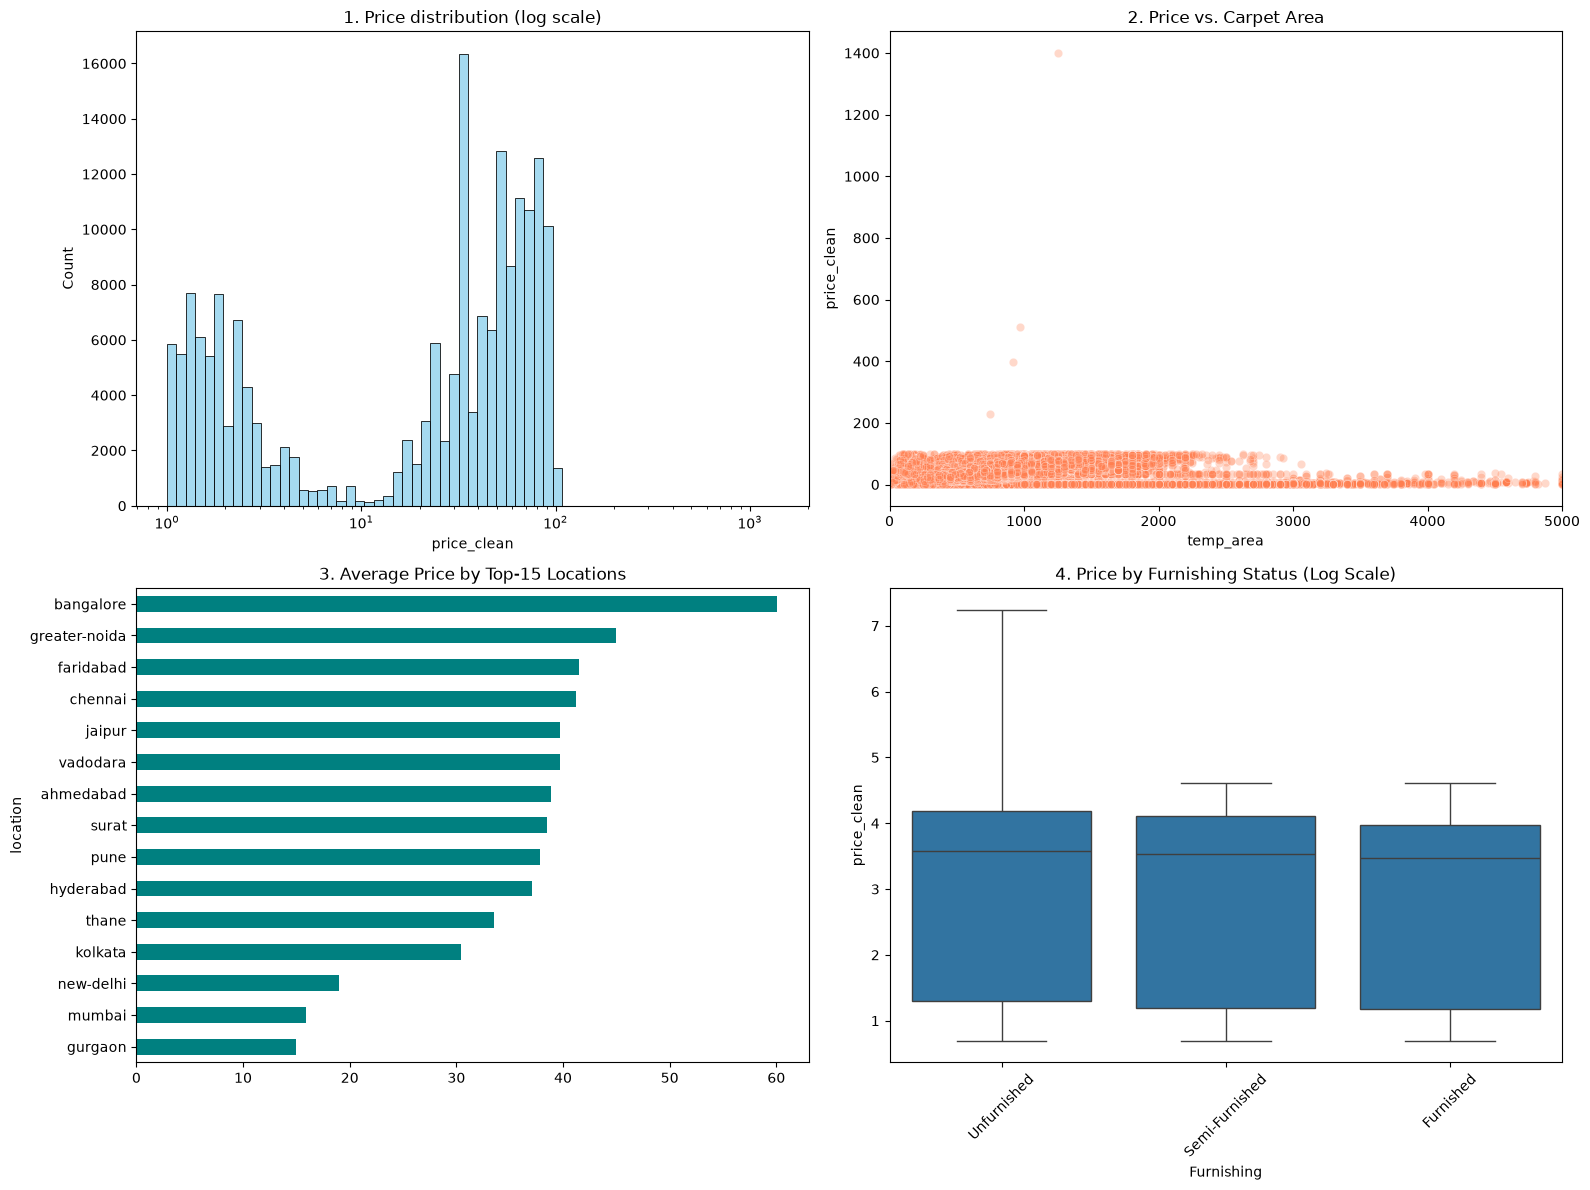

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure clean price exists for EDA (Quick clean just for plotting)
df_eda = df.dropna(subset=["Amount(in rupees)"]).copy()
df_eda["price_clean"] = df_eda["Amount(in rupees)"].astype(str).str.extract(r'([\d.]+)').astype(float)
df_eda["price_clean"] = df_eda["price_clean"].fillna(df_eda["price_clean"].median()) # temporary

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of the target price (log scale)
sns.histplot(df_eda["price_clean"], log_scale=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("1. Price distribution (log scale)")

# 2. Price vs. carpet area (scatter)
# Note: we extract a rough numeric area for the plot
df_eda["temp_area"] = df_eda["Carpet Area"].astype(str).str.extract(r'([\d.]+)').astype(float)
sns.scatterplot(data=df_eda, x="temp_area", y="price_clean", alpha=0.3, ax=axes[0, 1], color="coral")
axes[0, 1].set_title("2. Price vs. Carpet Area")
axes[0, 1].set_xlim(0, 5000) # limit x-axis to avoid extreme outliers in plot

# 3. Average price by top-15 locations (bar chart)
top_15_locs = df_eda["location"].value_counts().head(15).index
avg_price_loc = df_eda[df_eda["location"].isin(top_15_locs)].groupby("location")["price_clean"].mean().sort_values()
avg_price_loc.plot(kind="barh", ax=axes[1, 0], color="teal")
axes[1, 0].set_title("3. Average Price by Top-15 Locations")

# 4. Price by furnishing status (box plot)
sns.boxplot(data=df_eda, x="Furnishing", y=np.log1p(df_eda["price_clean"]), ax=axes[1, 1])
axes[1, 1].set_title("4. Price by Furnishing Status (Log Scale)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2.3 Cleaning & Feature Engineering

In [5]:
import re

# 1. Parse Price
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])

# 2. Parse Areas (Convert sqm to sqft)
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.lower().strip()
    match = re.search(r'([\d\.]+)', x)
    if not match:
        return None
    val = float(match.group(1))
    if 'sqm' in x or 'sq.m' in x:
        return val * 10.764
    return val

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

# 3. Floor Number
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.lower()
    if 'ground' in x:
        return 0
    if 'basement' in x:
        return -1
    match = re.search(r'(\d+)', x)
    return int(match.group(1)) if match else None

df["floor_num"] = df["Floor"].apply(parse_floor)

# 4. Bathroom / Balcony / Car Parking (Convert to numeric)
def extract_numeric(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r'(\d+)', str(x))
    return float(match.group(1)) if match else np.nan

df["bathroom"] = df["Bathroom"].apply(extract_numeric)
df["balcony"] = df["Balcony"].apply(extract_numeric)

# 5. High-cardinality categoricals (Top 50 locations)
top_50_locations = df["location"].value_counts().head(50).index.tolist()
df["location_grouped"] = df["location"].apply(lambda x: x if x in top_50_locations else "other")

# 6. Drop useless columns
cols_to_drop = ["Index", "Title", "Description", "Dimensions", "Amount(in rupees)", "Carpet Area", "Floor", "location"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

# 7. Remove outliers (Price per sqft 1st to 99th percentile)
df = df.dropna(subset=["carpet_area_sqft"]) # Ensure no null areas for division
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
p01 = df["price_per_sqft"].quantile(0.01)
p99 = df["price_per_sqft"].quantile(0.99)
df = df[(df["price_per_sqft"] >= p01) & (df["price_per_sqft"] <= p99)]
df = df.drop(columns=["price_per_sqft"])

print("Data Cleaning Finished! Current shape:", df.shape)

Data Cleaning Finished! Current shape: (99968, 19)


## 2.4 Build a Pipeline & Train

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Setup features (Exact names matching the PDF guide)
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

# Ensure columns exist and fill mostly empty columns to avoid key errors if they weren't in dataset
for col in categorical_features:
    if col not in df.columns:
        df[col] = "Unknown"

# Preprocessor Definition
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Baseline Linear Regression
lr_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])
lr_model.fit(X_train, y_train)

# Model 2: Random Forest Regressor
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42))
])
rf_model.fit(X_train, y_train)

print("Models Trained Successfully!")

Models Trained Successfully!


## 2.5 Evaluate

--- Linear Regression ---
MAE : 4560590.485339623
RMSE: 7503485.922582557
R²  : 0.7204053034000646
------------------------------
--- Random Forest ---
MAE : 1068133.0934526809
RMSE: 4100288.267646661
R²  : 0.9165105564985099
------------------------------


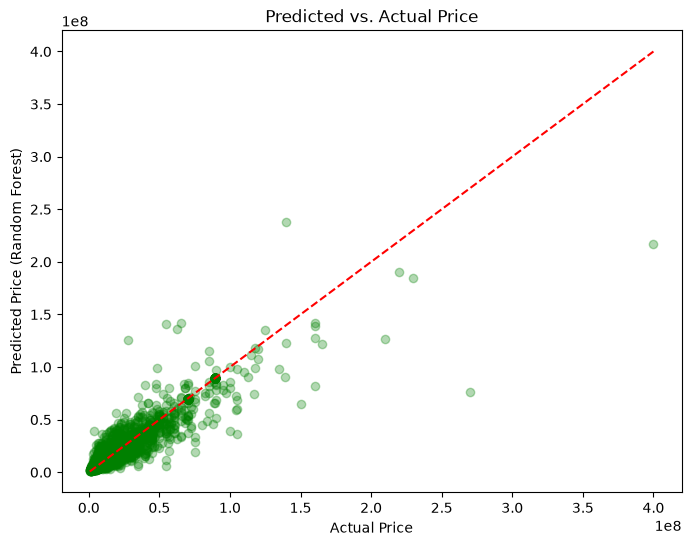

In [7]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(model_name, model_pipeline, X_t, y_t):
    pred = model_pipeline.predict(X_t)
    print(f"--- {model_name} ---")
    print("MAE :", mean_absolute_error(y_t, pred))
    print("RMSE:", root_mean_squared_error(y_t, pred))
    print("R²  :", r2_score(y_t, pred))
    print("-" * 30)
    return pred

# Evaluate both models
pred_lr = evaluate("Linear Regression", lr_model, X_test, y_test)
pred_rf = evaluate("Random Forest", rf_model, X_test, y_test)

# Predicted vs Actual Scatter Plot (For best model)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_rf, alpha=0.3, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price (Random Forest)")
plt.title("Predicted vs. Actual Price")
plt.show()

**Model Comparison & Conclusion** :Based on the evaluation metrics on the test set, Random Forest Regressor is the clear winner compared to the Linear Regression baseline.$R^2$ Score: Improved significantly from 0.720 (Linear Regression) to 0.917 (Random Forest), indicating that the ensemble model captures 91.7% of the variance in house prices.MAE & RMSE: The Mean Absolute Error dropped drastically from 4.56M to 1.07M, reducing average prediction error by over 76%.Decision: We select Random Forest as our final model for deployment (house_price.pkl) because tree-based models handle non-linear geographic and feature relationships much better than linear models in real estate pricing.

## 2.6 Export the Model

In [8]:
import joblib
import json

# Export the winning model
best_model = rf_model
joblib.dump(best_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

# Save the list of allowed locations for the frontend dropdown
locations_list = sorted(df["location_grouped"].dropna().unique().tolist())
with open("locations.json", "w") as f:
    json.dump(locations_list, f)

print("Export Complete! house_price.pkl and locations.json are ready.")

Reloaded prediction: [7500000.]
Export Complete! house_price.pkl and locations.json are ready.


In [10]:
import sklearn

print(sklearn.__version__)

1.9.0
